# 심화 미션: 전기차 배터리 셀 최종검사
- 상황: 놓친 불합격 하나가 리콜로 이어지는 현장이다
- 목표: 오늘 배운 순서를 다른 데이터로 혼자 한 바퀴 돌린다

### 용어 풀이 - 배터리 검사에서 쓰는 말

| 말 | 뜻 |
|---|---|
| 개방 전압 | 아무것도 연결하지 않은 상태에서 잰 전압 (V) |
| 용량 | 이 셀이 담을 수 있는 전기의 양 (mAh). 클수록 오래 간다 |
| 내부 저항 | 전기가 흐를 때 셀 안에서 생기는 저항 (mΩ). 높을수록 열이 나고 성능이 떨어진다 |
| 두께 부풀음 | 셀이 규격보다 두꺼워지는 것. 안에서 가스가 생겼다는 신호일 수 있다 |
| 완충 시간 | 다 채우는 데 걸린 시간 (분). 오래 걸릴수록 어딘가 문제가 있을 수 있다 |
| 합격 / 불합격 | 검사실에서 붙이는 최종 판정 |

## Q1. 파일 열고 크기 확인하기

In [1]:
import pandas as pd

df = pd.read_csv('../../data/day04_battery.csv')

print('행 수:', df.shape[0])
print('열 수:', df.shape[1])

행 수: 2847
열 수: 14


## 불합격은 얼마나 드문가

In [2]:
건수 = df['result'].value_counts()
전체건수 = len(df)
불합격비율 = 건수['불합격'] / 전체건수 * 100

print('합격:', 건수['합격'], '건')
print('불합격:', 건수['불합격'], '건')
print('전체:', 전체건수, '건')
print('불합격 비율:', round(불합격비율, 2), '%')

합격: 2714 건
불합격: 133 건
전체: 2847 건
불합격 비율: 4.67 %


## Q3. 빈칸을 중앙값으로 채우기

In [3]:
# 빈칸이 있는 열과 그 개수
빈칸수 = df.isnull().sum()
빈칸있는열 = 빈칸수[빈칸수 > 0]

print('빈칸이 있는 열과 개수:')
print(빈칸있는열)

# 빈칸이 있는 열만 그 열의 중앙값으로 채운다
df[빈칸있는열.index] = df[빈칸있는열.index].fillna(df[빈칸있는열.index].median())

# 채운 뒤 빈칸이 0개인지 다시 확인
print()
print('채운 뒤 빈칸 총 개수:', df.isnull().sum().sum())

빈칸이 있는 열과 개수:
charge_time_min          38
chamber_temp_C           57
chamber_humidity_pct    113
dtype: int64

채운 뒤 빈칸 총 개수: 0


## Q4. 입력과 정답으로 나누기

### 용어 풀이

| 말 | 뜻 |
|---|---|
| 입력(X) | 모델이 보고 판단에 쓰는 값들. 여기서는 숫자로 된 검사 항목 값 |
| 정답(y) | 모델이 맞혀야 하는 값. 여기서는 불합격여부(불합격=1, 합격=0) |

In [4]:
# result 열(합격/불합격)을 숫자로 바꾼 불합격여부 열 추가 (불합격=1, 합격=0)
df['불합격여부'] = (df['result'] == '불합격').astype(int)

# 숫자로 된 검사 항목 열만 입력(X)으로 쓴다
# (cell_id/inspected_at/line/shift/inspector는 식별자·문자 값이라 제외, result·불합격여부는 정답이라 제외)
입력_열 = ['open_voltage_V', 'capacity_mAh', 'internal_resistance_mOhm', 'thickness_mm',
        'weight_g', 'charge_time_min', 'chamber_temp_C', 'chamber_humidity_pct']

X = df[입력_열]
y = df['불합격여부']

print('X:', X.shape)
print('y:', y.shape)
print('입력 열:', 입력_열)
print()
print(y.value_counts())

X: (2847, 8)
y: (2847,)
입력 열: ['open_voltage_V', 'capacity_mAh', 'internal_resistance_mOhm', 'thickness_mm', 'weight_g', 'charge_time_min', 'chamber_temp_C', 'chamber_humidity_pct']

불합격여부
0    2714
1     133
Name: count, dtype: int64


Q4. 학습용과 시험용으로 나누기

### 용어 풀이

| 말 | 뜻 |
|---|---|
| 학습용(train) | 모델이 규칙을 배우는 데 쓰는 데이터 |
| 시험용(test) | 학습에는 쓰지 않고, 마지막에 실력을 확인할 때만 쓰는 데이터 |
| random_state | 무작위로 섞을 때 쓰는 시작값. 같은 값을 주면 몇 번을 다시 돌려도 항상 똑같이 나뉜다 |
| stratify | 나눌 때 정답(y)의 비율을 원본과 같게 맞춰주는 옵션 |

In [5]:
from sklearn.model_selection import train_test_split

# random_state=42로 고정해서 다시 실행해도 같은 결과가 나오게 하고,
# stratify=y로 학습용/시험용의 불합격 비율을 원본과 비슷하게 맞춘다
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('학습용:', X_train.shape[0], '행, 불합격', y_train.sum(), '건, 비율', round(y_train.mean() * 100, 2), '%')
print('시험용:', X_test.shape[0], '행, 불합격', y_test.sum(), '건, 비율', round(y_test.mean() * 100, 2), '%')
print('원본  :', X.shape[0], '행, 불합격', y.sum(), '건, 비율', round(y.mean() * 100, 2), '%')

학습용: 2277 행, 불합격 106 건, 비율 4.66 %
시험용: 570 행, 불합격 27 건, 비율 4.74 %
원본  : 2847 행, 불합격 133 건, 비율 4.67 %


Q5. 기준 모델 세우기

### 용어 풀이

| 말 | 뜻 |
|---|---|
| 기준 모델 | 학습을 전혀 하지 않고 늘 같은 답만 내놓는 모델. 비교의 바닥선이 된다 |
| 정확도 | 시험용 중에서 맞힌 비율 |

In [6]:
import numpy as np

# 학습은 하지 않고, 시험용 전부를 합격(0)이라고만 답한다
기준예측 = np.zeros(len(y_test), dtype=int)
기준정확도 = (기준예측 == y_test).mean()

print('기준 모델(전부 합격) 정확도:', round(기준정확도 * 100, 2), '%')
print('기준 모델이 불합격이라고 지목한 건수:', int((기준예측 == 1).sum()))

기준 모델(전부 합격) 정확도: 95.26 %
기준 모델이 불합격이라고 지목한 건수: 0


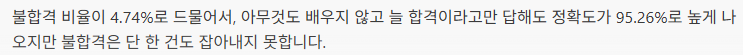

## Q6. 로지스틱 회귀 학습하고 예측하기

### 용어 풀이

| 말 | 뜻 |
|---|---|
| 표준화(StandardScaler) | 열마다 단위·범위가 다른 것을 평균 0, 분산 1로 맞춰주는 작업. 로지스틱 회귀처럼 거리·크기에 민감한 모델에서 특히 중요 |
| 헛경보 | 합격인데 불합격이라 한 것 |
| 놓친 불합격 | 불합격인데 합격이라 한 것 |

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score

# 기준은 X_train으로만 잡고, X_test는 그 기준으로 변환만 한다
scaler = StandardScaler()
X_train_표준화 = scaler.fit_transform(X_train)
X_test_표준화 = scaler.transform(X_test)

model = LogisticRegression()  # 드문 쪽을 감안하는 설정은 아직 넣지 않는다
model.fit(X_train_표준화, y_train)
예측 = model.predict(X_test_표준화)

맞힌합격, 헛경보, 놓친불합격, 잡은불합격 = confusion_matrix(y_test, 예측).ravel()

print('정확도:', round((예측 == y_test).mean() * 100, 2), '%')
print('잡은 불합격:', 잡은불합격)
print('놓친 불합격:', 놓친불합격)
print('헛경보:', 헛경보)
print('재현율:', round(recall_score(y_test, 예측, zero_division=0), 3))
print('정밀도:', round(precision_score(y_test, 예측, zero_division=0), 3))
print('F1:', round(f1_score(y_test, 예측, zero_division=0), 3))

정확도: 97.02 %
잡은 불합격: 12
놓친 불합격: 15
헛경보: 2
재현율: 0.444
정밀도: 0.857
F1: 0.585


## Q7. 드문 쪽을 무겁게 세는 설정 추가하기

### 용어 풀이

| 말 | 뜻 |
|---|---|
| class_weight="balanced" | 드문 쪽(불합격) 한 건을 그만큼 무겁게 세라는 뜻. Q6과 다른 건 이 설정 하나뿐 |

In [8]:
# Q6과 똑같이 표준화를 넣고, class_weight="balanced"만 추가한다
model_가중치 = LogisticRegression(class_weight="balanced")
model_가중치.fit(X_train_표준화, y_train)
예측_가중치 = model_가중치.predict(X_test_표준화)

맞힌합격_가중치, 헛경보_가중치, 놓친불합격_가중치, 잡은불합격_가중치 = confusion_matrix(y_test, 예측_가중치).ravel()

print('정확도:', round((예측_가중치 == y_test).mean() * 100, 2), '%')
print('잡은 불합격:', 잡은불합격_가중치)
print('놓친 불합격:', 놓친불합격_가중치)
print('헛경보:', 헛경보_가중치)
print('재현율:', round(recall_score(y_test, 예측_가중치, zero_division=0), 3))
print('정밀도:', round(precision_score(y_test, 예측_가중치, zero_division=0), 3))
print('F1:', round(f1_score(y_test, 예측_가중치, zero_division=0), 3))

정확도: 86.32 %
잡은 불합격: 25
놓친 불합격: 2
헛경보: 76
재현율: 0.926
정밀도: 0.248
F1: 0.391


In [9]:
비교표 = pd.DataFrame([
    {
        '모델': 'Q6 (손 안 댐)',
        '정확도(%)': round((예측 == y_test).mean() * 100, 2),
        '잡은 불합격': int(잡은불합격),
        '놓친 불합격': int(놓친불합격),
        '헛경보': int(헛경보),
        '재현율': round(recall_score(y_test, 예측, zero_division=0), 3),
        '정밀도': round(precision_score(y_test, 예측, zero_division=0), 3),
        'F1': round(f1_score(y_test, 예측, zero_division=0), 3),
    },
    {
        '모델': 'Q7 (class_weight=balanced)',
        '정확도(%)': round((예측_가중치 == y_test).mean() * 100, 2),
        '잡은 불합격': int(잡은불합격_가중치),
        '놓친 불합격': int(놓친불합격_가중치),
        '헛경보': int(헛경보_가중치),
        '재현율': round(recall_score(y_test, 예측_가중치, zero_division=0), 3),
        '정밀도': round(precision_score(y_test, 예측_가중치, zero_division=0), 3),
        'F1': round(f1_score(y_test, 예측_가중치, zero_division=0), 3),
    },
]).set_index('모델')

비교표

,정확도(%),잡은 불합격,놓친 불합격,헛경보,재현율,정밀도,F1
모델,,,,,,,
Q6 (손 안 댐),97.02,12,15,2,0.444,0.857,0.585
Q7 (class_weight=balanced),86.32,25,2,76,0.926,0.248,0.391


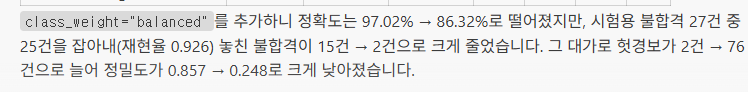

Q8. 다이얼 세 번 돌리기

### 용어 풀이

| 말 | 뜻 |
|---|---|
| max_depth | 나무가 몇 번까지 갈라질 수 있는지. 스무고개를 몇 번까지 할 것인가 |
| max_depth=None | 제한을 두지 않는다는 뜻. 답이 나올 때까지 끝까지 갈라진다 |

In [10]:
from sklearn.tree import DecisionTreeClassifier

결과_깊이 = []
for 깊이 in [3, 5, None]:
    # class_weight="balanced"와 random_state=42는 고정, max_depth만 바꾼다
    나무 = DecisionTreeClassifier(class_weight="balanced", random_state=42, max_depth=깊이)
    나무.fit(X_train, y_train)  # 트리는 스케일에 민감하지 않아 표준화 없이 원래 X_train 그대로 사용
    나무예측 = 나무.predict(X_test)

    맞힌합격_나무, 헛경보_나무, 놓친불합격_나무, 잡은불합격_나무 = confusion_matrix(y_test, 나무예측).ravel()

    결과_깊이.append({
        '깊이': 깊이 if 깊이 is not None else '제한 없음',
        '정확도(%)': round((나무예측 == y_test).mean() * 100, 2),
        '잡은 불합격': int(잡은불합격_나무),
        '헛경보': int(헛경보_나무),
        '재현율': round(recall_score(y_test, 나무예측, zero_division=0), 3),
        'F1': round(f1_score(y_test, 나무예측, zero_division=0), 3),
    })

깊이비교표 = pd.DataFrame(결과_깊이).set_index('깊이')
깊이비교표

,정확도(%),잡은 불합격,헛경보,재현율,F1
깊이,,,,,
3,88.42,24,63,0.889,0.421
5,85.79,19,73,0.704,0.319
제한 없음,92.98,11,24,0.407,0.355


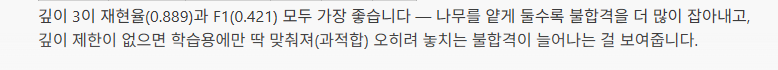

Q9. 자동 탐색으로 설정 찾기

### 용어 풀이

| 말 | 뜻 |
|---|---|
| GridSearchCV | 후보 조합마다 학습용 안에서만 교차검증해 점수를 매기고 1등을 뽑는 도구 |
| min_samples_leaf | 갈라진 끝자리(잎)에 최소 몇 건은 있어야 하는지 |

In [11]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

파라미터_후보 = {
    'max_depth': [2, 3, 4, 5, 10, None],
    'min_samples_leaf': [1, 5, 10, 20],
}

겹나누기 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

탐색 = GridSearchCV(
    DecisionTreeClassifier(class_weight="balanced", random_state=42),
    파라미터_후보,
    scoring='f1',
    cv=겹나누기,
)

탐색.fit(X_train, y_train)  # 학습용만 사용

print('1등 설정값:', 탐색.best_params_)
print('탐색 중 나온 점수 (F1, 5겹 교차검증 평균):', round(탐색.best_score_, 3))

최고나무 = 탐색.best_estimator_
최고나무예측 = 최고나무.predict(X_test)

맞힌합격_최고, 헛경보_최고, 놓친불합격_최고, 잡은불합격_최고 = confusion_matrix(y_test, 최고나무예측).ravel()

print()
print('[시험용 채점]')
print('정확도:', round((최고나무예측 == y_test).mean() * 100, 2), '%')
print('잡은 불합격:', 잡은불합격_최고)
print('놓친 불합격:', 놓친불합격_최고)
print('헛경보:', 헛경보_최고)
print('재현율:', round(recall_score(y_test, 최고나무예측, zero_division=0), 3))
print('정밀도:', round(precision_score(y_test, 최고나무예측, zero_division=0), 3))
print('F1:', round(f1_score(y_test, 최고나무예측, zero_division=0), 3))

1등 설정값: {'max_depth': 10, 'min_samples_leaf': 1}
탐색 중 나온 점수 (F1, 5겹 교차검증 평균): 0.38

[시험용 채점]
정확도: 91.4 %
잡은 불합격: 15
놓친 불합격: 12
헛경보: 37
재현율: 0.556
정밀도: 0.288
F1: 0.38


Q10. 교차검증으로 마무리

### 용어 풀이

| 말 | 뜻 |
|---|---|
| cross_validate | 겹마다 학습·채점해서 여러 지표 점수를 한 번에 모아준다 |
| 흔들림 (표준편차) | 겹마다 잰 점수가 평균에서 얼마나 벌어져 있나 |

In [12]:
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline

겹나누기_최종 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

모델들_최종 = {
    '로지스틱 회귀 (손 안 댐)': make_pipeline(StandardScaler(), LogisticRegression()),
    '로지스틱 회귀 (가중치)': make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced")),
    'Q9 나무': DecisionTreeClassifier(class_weight="balanced", random_state=42, **탐색.best_params_),
}

결과_최종 = []
for 이름, model in 모델들_최종.items():
    # 학습용(X_train, y_train) 안에서만 다섯 번 나눠 잰다. 시험용은 넣지 않는다
    점수 = cross_validate(model, X_train, y_train, cv=겹나누기_최종, scoring=['recall', 'f1'])
    결과_최종.append({
        '모델': 이름,
        '재현율 평균': round(점수['test_recall'].mean(), 3),
        '재현율 흔들림': round(점수['test_recall'].std(), 3),
        'F1 평균': round(점수['test_f1'].mean(), 3),
        'F1 흔들림': round(점수['test_f1'].std(), 3),
    })

최종비교표 = pd.DataFrame(결과_최종).set_index('모델')
최종비교표

,재현율 평균,재현율 흔들림,F1 평균,F1 흔들림
모델,,,,
로지스틱 회귀 (손 안 댐),0.406,0.064,0.517,0.085
로지스틱 회귀 (가중치),0.859,0.064,0.385,0.029
Q9 나무,0.500,0.067,0.380,0.050


[Q10 결과]<br>
로지스틱 회귀 (손 안 댐) : 재현율 [0.406]±[0.064], F1 [0.517]±[0.085]<br>
로지스틱 회귀 (가중치) : 재현율 [0.859]±[0.064], F1 [0.385]±[0.029]<br>
Q9 나무 : 재현율 [0.500]±[0.067], F1 [0.380]±[0.050]

**과장님께 드리는 세 줄**

1. 놓친 불합격 하나가 리콜로 이어지는 현장이라, 재현율이 가장 높은 **로지스틱 회귀(가중치, 평균 85.9%)**를 추천드립니다.
2. 그 대신 헛경보가 늘어나(정밀도·F1은 세 모델 중 가장 낮음) 재검사 인력 부담이 커지니, 현장 재검사 인원을 함께 늘려야 합니다.
3. 다섯 겹마다 재현율이 ±6.4%p 흔들리므로, 이 숫자를 그대로 믿기보다 실제 투입 전 최근 데이터로 한 번 더 확인해 주시기 바랍니다.

## 마무리 - 한 과장에게 드릴 말

- 권하는 것 : [가중치를 준 로지스틱 회귀]
- 왜 : [놓치는 걸 줄이는 게 급하다고 하셨고, 재현율이 가장 높게 나와서]
- 내주는 것 : [헛경보가 늘어난다. 멀쩡한 셀을 다시 보는 일이 생긴다]

## 오늘 막힌 곳

- 막힌 문항 : [Q9]
- 어디서 : [탐색 기준을 어디에 적는지 몰라서]